## Imports

In [ ]:
!pip install -q kaggle

In [ ]:
from google.colab import files

files.upload()

In [ ]:
! mkdir ~/.kaggle

! cp kaggle.json ~/.kaggle/

mkdir: cannot create directory ‘/root/.kaggle’: File exists


In [ ]:
! chmod 600 ~/.kaggle/kaggle.json

In [ ]:
%%capture
! kaggle datasets list

In [ ]:
!kaggle datasets download -d mohamedmustafa/real-life-violence-situations-dataset

Dataset URL: https://www.kaggle.com/datasets/mohamedmustafa/real-life-violence-situations-dataset
License(s): copyright-authors
real-life-violence-situations-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!unzip real-life-violence-situations-dataset.zip -d /content/real-life-violence-situations-dataset

# !wget --no-check-certificate https://www.crcv.ucf.edu/data/UCF50.rar

# !unrar x UCF50.rar

In [5]:
%%capture
!pip install pafy moviepy youtube-dl


In [3]:
import os
import cv2
import pafy
import math
import random
import numpy as np
import datetime as dt
from collections import deque
import matplotlib.pyplot as plt

from moviepy.editor import *
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import plot_model


In [4]:
seed_constant = 27
DATASET_DIR = "/content/real-life-violence-situations-dataset/Real Life Violence Dataset"
np.random.seed(seed_constant)
random.seed(seed_constant)
tf.random.set_seed(seed_constant)

## visualization

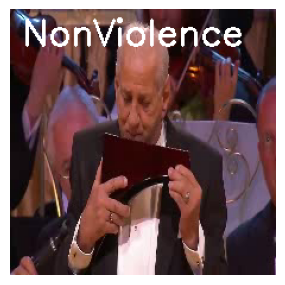

In [ ]:
# specifying size of the figures
plt.figure(figsize=(20,20))
#get the names of all classes/categories in UCF50
all_classes_names = os.listdir(DATASET_DIR)

# generate a list of 20 ramdom values. the values will be between 0-50,
# where 50 is the total number of class in the dataset.
random_range = random.sample(range(len(all_classes_names)),1)

# Iterating through all the generated random values.

for counter, random_index in enumerate(random_range,1):

  # Retrive a Class Name using the Random Index.
  selected_class_Name = all_classes_names[random_index]

  # Retreive the list of all the video files present in the randomly selected Class Directory.
  video_files_names_list = os.listdir(f'{DATASET_DIR}/{selected_class_Name}')

  # Randomly select a video file from the list retrieved from the randomly sele
  selected_video_file_name = random.choice(video_files_names_list)

  # Initialize a VideoCapture object to read from the video file.
  video_reader = cv2.VideoCapture(f'{DATASET_DIR}/{selected_class_Name}/{selected_video_file_name}')

  # Read the first frame of the video file.
  _, bgr_frame = video_reader.read()

  #Relaase the VideoCapture object
  video_reader.release()

  #Convert the frame from BGR into RGB format.
  rgb_frame = cv2.cvtColor(bgr_frame,cv2.COLOR_BGR2RGB)

  #Write the class name on the video frame.
  cv2.putText(rgb_frame,selected_class_Name,(10,30),cv2.FONT_HERSHEY_SIMPLEX,1,(255,255,255),2)

  #Display the frame
  plt.subplot(5,4,counter);plt.imshow(rgb_frame);plt.axis('off')

##Preprocessing

In [5]:
# Specify the height and width to which each video frame will be resized in our dataset.
IMAGE_HEIGHT, IMAGE_WIDTH = 64,64

# Specify the number of frames of a video that will be fed to the model as one sequence.
SEQUENCE_LENGTH = 20

# Specify the directory containing the UCF50 dataset.
DATASET_DIR = "/content/real-life-violence-situations-dataset/Real Life Violence Dataset"

# Specify the list containing names of the classes used for training. Feel free to choose any set of classes.
CLASSES_LIST = ["NonViolence","Violence"]


In [6]:
def frames_extraction(video_path):
    '''
    This function will extract the required frames from a video after resizing and normalizing them.
    Args:
        video_path: The path of the video in the disk, whose frames are to be extracted.
    Returns:
        frames_list: A list containing the resized and normalized frames of the video.
    '''

    # Declare a list to store video frames.
    frames_list = []

    # Read the Video File using the VideoCapture object.
    video_reader = cv2.VideoCapture(video_path)

    # Get the total number of frames in the video.
    video_frames_count = int(video_reader.get(cv2.CAP_PROP_FRAME_COUNT))

    # Calculate the the interval after which frames will be added to the list.
    skip_frames_window = max(int(video_frames_count/SEQUENCE_LENGTH), 1)

    # Iterate through the Video Frames.
    for frame_counter in range(SEQUENCE_LENGTH):

        # Set the current frame position of the video.
        video_reader.set(cv2.CAP_PROP_POS_FRAMES, frame_counter * skip_frames_window)

        # Reading the frame from the video.
        success, frame = video_reader.read()

        # Check if Video frame is not successfully read then break the loop
        if not success:
            break

        # Resize the Frame to fixed height and width.
        resized_frame = cv2.resize(frame, (IMAGE_HEIGHT, IMAGE_WIDTH))

        # Normalize the resized frame by dividing it with 255 so that each pixel value then lies between 0 and 1
        normalized_frame = resized_frame / 255

        # Append the normalized frame into the frames list
        frames_list.append(normalized_frame)

    # Release the VideoCapture object.
    video_reader.release()

    # Return the frames list.
    return frames_list

##dataset

In [7]:
def create_dataset():
    '''
    This function will extract the data of the selected classes and create the required dataset.
    Returns:
        features:          A list containing the extracted frames of the videos.
        labels:            A list containing the indexes of the classes associated with the videos.
        video_files_paths: A list containing the paths of the videos in the disk.
    '''

    # Declared Empty Lists to store the features, labels and video file path values.
    features = []
    labels = []
    video_files_paths = []

    # Iterating through all the classes mentioned in the classes list
    for class_index, class_name in enumerate(CLASSES_LIST):

        # Display the name of the class whose data is being extracted.
        print(f'Extracting Data of Class: {class_name}')

        # Get the list of video files present in the specific class name directory.
        files_list = os.listdir(os.path.join(DATASET_DIR, class_name))

        # Iterate through all the files present in the files list.
        for file_index, file_name in enumerate(files_list):
            # Get the complete video path.
            video_file_path = os.path.join(DATASET_DIR, class_name, file_name)

            try:
                # Extract the frames of the video file.
                frames = frames_extraction(video_file_path)

                # Check if the extracted frames are equal to the SEQUENCE_LENGTH specified above.
                # So ignore the videos having frames less than the SEQUENCE_LENGTH.
                if len(frames) == SEQUENCE_LENGTH:
                    # Append the data to their respective lists.
                    features.append(frames)
                    labels.append(class_index)
                    video_files_paths.append(video_file_path)
                else:
                    print(f'Skipping {video_file_path}: insufficient frames')
            except Exception as e:
                print(f'Error processing {video_file_path}: {e}')

            # Print progress every 100 videos
            if (file_index + 1) % 100 == 0:
                print(f'Processed {file_index + 1}/{len(files_list)} videos in class {class_name}')

    # Converting the list to numpy arrays
    features = np.asarray(features)
    labels = np.array(labels)

    # Return the frames, class index, and video file path.
    return features, labels, video_files_paths

In [ ]:
# Create the dataset.
features, labels, video_files_paths = create_dataset()

In [ ]:
# Using Keras's to_categorical method to convert labels into one-hot-encoded vectors
one_hot_encoded_labels = to_categorical(labels)

##Train

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
# Split the Data into Train ( 75% ) and Test Set ( 25% ).
features_train, features_test, labels_train, labels_test = train_test_split(features, one_hot_encoded_labels,
                                                                            test_size = 0.25, shuffle = True,
                                                                            random_state = seed_constant)

In [10]:
def create_LRCN_model():
    '''
    This function will construct the required LRCN model.
    Returns:
        model: It is the required constructed LRCN model.
    '''

    # We will use a Sequential model for model construction.
    model = Sequential()

    # Define the Model Architecture.
    ########################################################################################################################

    model.add(TimeDistributed(Conv2D(16, (3, 3), padding='same',activation = 'relu'),
                              input_shape = (SEQUENCE_LENGTH, IMAGE_HEIGHT, IMAGE_WIDTH, 3)))

    model.add(TimeDistributed(MaxPooling2D((4, 4))))
    model.add(TimeDistributed(Dropout(0.25)))

    model.add(TimeDistributed(Conv2D(32, (3, 3), padding='same',activation = 'relu')))
    model.add(TimeDistributed(MaxPooling2D((4, 4))))
    model.add(TimeDistributed(Dropout(0.25)))

    model.add(TimeDistributed(Conv2D(64, (3, 3), padding='same',activation = 'relu')))
    model.add(TimeDistributed(MaxPooling2D((2, 2))))
    model.add(TimeDistributed(Dropout(0.25)))

    model.add(TimeDistributed(Conv2D(64, (3, 3), padding='same',activation = 'relu')))
    model.add(TimeDistributed(MaxPooling2D((2, 2))))
    #model.add(TimeDistributed(Dropout(0.25)))

    model.add(TimeDistributed(Flatten()))

    model.add(LSTM(32))

    model.add(Dense(len(CLASSES_LIST), activation = 'softmax'))

    ########################################################################################################################

    # Display the models summary.
    model.summary()

    # Return the constructed LRCN model.
    return model

In [ ]:
# Construct the required LRCN model.
LRCN_model = create_LRCN_model()

# Display the success message.
print("Model Created Successfully!")



Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 time_distributed_12 (TimeD  (None, 20, 64, 64, 16)    448       
 istributed)                                                     
                                                                 
 time_distributed_13 (TimeD  (None, 20, 16, 16, 16)    0         
 istributed)                                                     
                                                                 
 time_distributed_14 (TimeD  (None, 20, 16, 16, 16)    0         
 istributed)                                                     
                                                                 
 time_distributed_15 (TimeD  (None, 20, 16, 16, 32)    4640      
 istributed)                                                     
                                                                 
 time_distributed_16 (TimeD  (None, 20, 4, 4, 32)     

In [ ]:
# Plot the structure of the contructed LRCN model.
plot_model(LRCN_model, to_file = 'LRCN_model_structure_plot.png', show_shapes = True, show_layer_names = True)

You must install pydot (`pip install pydot`) and install graphviz (see instructions at https://graphviz.gitlab.io/download/) for plot_model to work.


In [ ]:
# Create an Instance of Early Stopping Callback.
early_stopping_callback = EarlyStopping(monitor = 'val_loss', patience = 15, mode = 'min', restore_best_weights = True)

# Compile the model and specify loss function, optimizer and metrics to the model.
LRCN_model.compile(loss = 'categorical_crossentropy', optimizer = 'Adam', metrics = ["accuracy"])

# Start training the model.
LRCN_model_training_history = LRCN_model.fit(x = features_train, y = labels_train, epochs = 70, batch_size = 4 ,
                                             shuffle = True, validation_split = 0.2)

Epoch 1/70
300/300 [==============================] - 10s 27ms/step - loss: 0.7008 - accuracy: 0.5075 - val_loss: 0.6912 - val_accuracy: 0.5333
Epoch 2/70
300/300 [==============================] - 7s 24ms/step - loss: 0.6856 - accuracy: 0.5450 - val_loss: 0.6718 - val_accuracy: 0.5200
Epoch 3/70
300/300 [==============================] - 7s 24ms/step - loss: 0.6768 - accuracy: 0.5792 - val_loss: 0.6551 - val_accuracy: 0.6133
Epoch 4/70
300/300 [==============================] - 7s 24ms/step - loss: 0.6113 - accuracy: 0.6533 - val_loss: 0.6812 - val_accuracy: 0.5533
Epoch 5/70
300/300 [==============================] - 7s 24ms/step - loss: 0.5083 - accuracy: 0.7525 - val_loss: 0.5740 - val_accuracy: 0.6833
Epoch 6/70
300/300 [==============================] - 7s 24ms/step - loss: 0.4355 - accuracy: 0.8083 - val_loss: 0.4669 - val_accuracy: 0.7967
Epoch 7/70
300/300 [==============================] - 7s 24ms/step - loss: 0.3902 - accuracy: 0.8275 - val_loss: 0.4475 - val_accuracy: 0.796

In [ ]:
# Evaluate the trained model.
model_evaluation_history = LRCN_model.evaluate(features_test, labels_test)

16/16 [==============================] - 1s 40ms/step - loss: 0.5166 - accuracy: 0.8640


## Save model

In [ ]:
# Get the loss and accuracy from model_evaluation_history.
model_evaluation_loss, model_evaluation_accuracy = model_evaluation_history

# Define the string date format.
# Get the current Date and Time in a DateTime Object.
# Convert the DateTime object to string according to the style mentioned in date_time_format string.
date_time_format = '%Y_%m_%d__%H_%M_%S'
current_date_time_dt = dt.datetime.now()
current_date_time_string = dt.datetime.strftime(current_date_time_dt, date_time_format)

# Define a useful name for our model to make it easy for us while navigating through multiple saved models.
model_file_name = f'Keras_LRCN_model___Date_Time_{current_date_time_string}___Loss_{model_evaluation_loss}___Accuracy_{model_evaluation_accuracy}.keras'

# Save the Model.
LRCN_model.save(model_file_name)

## Download video and test models

### download videos function

In [ ]:
# !pip install yt_dlp

In [ ]:

# import os
# from yt_dlp import YoutubeDL

In [ ]:

# def download_youtube_videos(youtube_video_url, output_directory):
#     '''
#     This function downloads the YouTube video whose URL is passed to it as an argument.
#     Args:
#         youtube_video_url: URL of the video that is required to be downloaded.
#         output_directory:  The directory path to which the video needs to be stored after downloading.
#     Returns:
#         title: The title of the downloaded YouTube video.
#     '''

#     # Options for yt-dlp
#     ydl_opts = {
#         'outtmpl': os.path.join(output_directory, '%(title)s.%(ext)s'),
#         'quiet': True,
#     }

#     with YoutubeDL(ydl_opts) as ydl:
#         info_dict = ydl.extract_info(youtube_video_url, download=True)
#         title = info_dict.get('title', None)

#     return title


In [ ]:
# # Make the Output directory if it does not exist

# test_videos_directory = 'test_videos'
# os.makedirs(test_videos_directory, exist_ok = True)

# # Download a YouTube Video.
# video_title = download_youtube_videos('https://www.youtube.com/watch?v=8u0qjmHIOcE', test_videos_directory)

# # Get the YouTube Video's path we just downloaded.
# input_video_file_path = f'{test_videos_directory}/{video_title}.mp4'

### predict on videos

In [11]:
def predict_on_video(video_file_path, output_file_path, SEQUENCE_LENGTH):
    '''
    This function will perform action recognition on a video using the LRCN model.
    Args:
    video_file_path:  The path of the video stored in the disk on which the action recognition is to be performed.
    output_file_path: The path where the ouput video with the predicted action being performed overlayed will be stored.
    SEQUENCE_LENGTH:  The fixed number of frames of a video that can be passed to the model as one sequence.
    '''

    # Initialize the VideoCapture object to read from the video file.
    video_reader = cv2.VideoCapture(video_file_path)

    # Get the width and height of the video.
    original_video_width = int(video_reader.get(cv2.CAP_PROP_FRAME_WIDTH))
    original_video_height = int(video_reader.get(cv2.CAP_PROP_FRAME_HEIGHT))

    # Initialize the VideoWriter Object to store the output video in the disk.
    video_writer = cv2.VideoWriter(output_file_path, cv2.VideoWriter_fourcc('M', 'P', '4', 'V'),
                                   video_reader.get(cv2.CAP_PROP_FPS), (original_video_width, original_video_height))

    # Declare a queue to store video frames.
    frames_queue = deque(maxlen = SEQUENCE_LENGTH)

    # Initialize a variable to store the predicted action being performed in the video.
    predicted_class_name = ''

    # Iterate until the video is accessed successfully.
    while video_reader.isOpened():

        # Read the frame.
        ok, frame = video_reader.read()

        # Check if frame is not read properly then break the loop.
        if not ok:
            break

        # Resize the Frame to fixed Dimensions.
        resized_frame = cv2.resize(frame, (IMAGE_HEIGHT, IMAGE_WIDTH))

        # Normalize the resized frame by dividing it with 255 so that each pixel value then lies between 0 and 1.
        normalized_frame = resized_frame / 255

        # Appending the pre-processed frame into the frames list.
        frames_queue.append(normalized_frame)

        # Check if the number of frames in the queue are equal to the fixed sequence length.
        if len(frames_queue) == SEQUENCE_LENGTH:

            # Pass the normalized frames to the model and get the predicted probabilities.
            predicted_labels_probabilities = LRCN_model.predict(np.expand_dims(frames_queue, axis = 0))[0]

            # Get the index of class with highest probability.
            predicted_label = np.argmax(predicted_labels_probabilities)

            # Get the class name using the retrieved index.
            predicted_class_name = CLASSES_LIST[predicted_label]

        # Write predicted class name on top of the frame.
        cv2.putText(frame, predicted_class_name, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

        # Write The frame into the disk using the VideoWriter Object.
        video_writer.write(frame)

    # Release the VideoCapture and VideoWriter objects.
    video_reader.release()
    video_writer.release()

In [ ]:
# Perform Action Recognition on the Test Video.
test_videos_directory = 'test_videos'
os.makedirs(test_videos_directory, exist_ok = True)

predict_on_video("/content/Street fight tko 30 seconds.mp4","/content/test_videos/Output2.mp4",SEQUENCE_LENGTH)
# Display the output video.


1/1 [==============================] - 0s 29ms/step


In [12]:
def predict_single_action(video_file_path, SEQUENCE_LENGTH):
    '''
    This function will perform single action recognition prediction on a video using the LRCN model.
    Args:
    video_file_path:  The path of the video stored in the disk on which the action recognition is to be performed.
    SEQUENCE_LENGTH:  The fixed number of frames of a video that can be passed to the model as one sequence.
    '''

    # Initialize the VideoCapture object to read from the video file.
    video_reader = cv2.VideoCapture(video_file_path)

    # Get the width and height of the video.
    original_video_width = int(video_reader.get(cv2.CAP_PROP_FRAME_WIDTH))
    original_video_height = int(video_reader.get(cv2.CAP_PROP_FRAME_HEIGHT))

    # Declare a list to store video frames we will extract.
    frames_list = []

    # Initialize a variable to store the predicted action being performed in the video.
    predicted_class_name = ''

    # Get the number of frames in the video.
    video_frames_count = int(video_reader.get(cv2.CAP_PROP_FRAME_COUNT))

    # Calculate the interval after which frames will be added to the list.
    skip_frames_window = max(int(video_frames_count/SEQUENCE_LENGTH),1)

    # Iterating the number of times equal to the fixed length of sequence.
    for frame_counter in range(SEQUENCE_LENGTH):

        # Set the current frame position of the video.
        video_reader.set(cv2.CAP_PROP_POS_FRAMES, frame_counter * skip_frames_window)

        # Read a frame.
        success, frame = video_reader.read()

        # Check if frame is not read properly then break the loop.
        if not success:
            break

        # Resize the Frame to fixed Dimensions.
        resized_frame = cv2.resize(frame, (IMAGE_HEIGHT, IMAGE_WIDTH))

        # Normalize the resized frame by dividing it with 255 so that each pixel value then lies between 0 and 1.
        normalized_frame = resized_frame / 255

        # Appending the pre-processed frame into the frames list
        frames_list.append(normalized_frame)

    # Passing the  pre-processed frames to the model and get the predicted probabilities.
    predicted_labels_probabilities = LRCN_model.predict(np.expand_dims(frames_list, axis = 0))[0]

    # Get the index of class with highest probability.
    predicted_label = np.argmax(predicted_labels_probabilities)

    # Get the class name using the retrieved index.
    predicted_class_name = CLASSES_LIST[predicted_label]

    # Display the predicted action along with the prediction confidence.
    print(f'Action Predicted: {predicted_class_name}\nConfidence: {predicted_labels_probabilities[predicted_label]}')

    # Release the VideoCapture object.
    video_reader.release()

In [ ]:
predict_single_action("/content/test.mp4",SEQUENCE_LENGTH)

1/1 [==============================] - 0s 31ms/step
Action Predicted: NonViolence
Confidence: 0.9957102537155151


In [ ]:
from tensorflow.keras.models import load_model

# Correct path to the model file
path_to_model = "ViolenceModelFinal.keras"

# Load the model
LRCN_model = load_model(path_to_model)